<a href="https://colab.research.google.com/github/Niharika-2226/Hybrid-Cataract-Detection-System/blob/main/Hybrid_Cataract_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
# Image processing
import cv2
from skimage.feature import graycomatrix, graycoprops
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, roc_auc_score
)
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Cataract_dataset

ls: cannot access '/content/drive/MyDrive/Cataract_dataset': Software caused connection abort


In [ ]:
# =======================================
# STEP 2.1: DATASET PATH (GOOGLE DRIVE)
# =======================================
BASE_DIR = "/content/drive/MyDrive/Cataract_dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
CATEGORIES = ["cataract", "normal"]
IMG_SIZE = 224
print("Train path:", TRAIN_DIR)
print("Test path :", TEST_DIR)

Train path: /content/drive/MyDrive/Cataract_dataset/train
Test path : /content/drive/MyDrive/Cataract_dataset/test


In [ ]:
# ================================
# STEP 2.2: LOAD IMAGES & LABELS
# ================================

def load_images_and_labels(folder_path):
    images = []
    labels = []

    for category in CATEGORIES:
        category_path = os.path.join(folder_path, category)
        label = CATEGORIES.index(category)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)

            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                images.append(img)
                labels.append(label)
            except:
                pass

    return images, labels

# Load data
train_images, train_labels = load_images_and_labels(TRAIN_DIR)
test_images, test_labels = load_images_and_labels(TEST_DIR)

print("Training images loaded:", len(train_images))
print("Testing images loaded :", len(test_images))

Training images loaded: 488
Testing images loaded : 118


In [ ]:
# ================================
# STEP 2.3: CONVERT TO NUMPY ARRAYS
# ================================
X_train = np.array(train_images)
y_train = np.array(train_labels)
X_test = np.array(test_images)
y_test = np.array(test_labels)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (488, 224, 224, 3)
y_train shape: (488,)
X_test shape : (118, 224, 224, 3)
y_test shape : (118,)


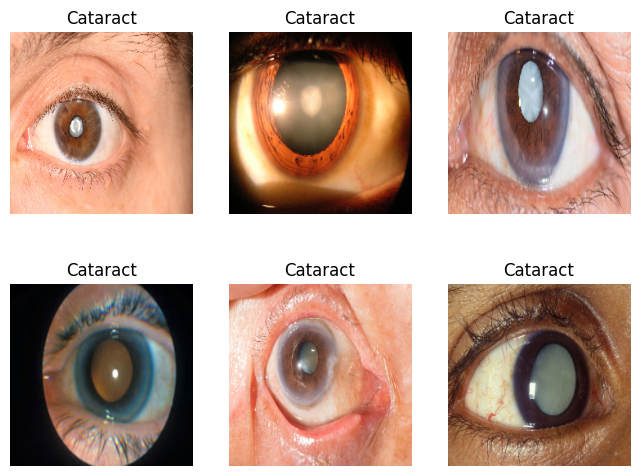

In [ ]:
# ================================
# STEP 2.4: VISUALIZE SAMPLE IMAGES
# ================================

plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title("Cataract" if y_train[i] == 0 else "Normal")
    plt.axis("off")

plt.show()

In [ ]:
# ================================
# STEP 2.5: CLASS DISTRIBUTION
# ================================

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{CATEGORIES[label]} images in training set: {count}")

cataract images in training set: 242
normal images in training set: 246


In [ ]:
# ================================
# STEP 3.1: IMAGE NORMALIZATION
# ================================
# Convert pixel values from [0,255] → [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Normalization completed.")
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Normalization completed.
Min pixel value: 0.0
Max pixel value: 1.0


In [ ]:
# ================================
# STEP 3.2: DATA AUGMENTATION
# ================================

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator()

In [ ]:
# ================================
# STEP 3.3: GENERATORS
# ================================

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=32,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=32,
    shuffle=False
)

print("Data generators created successfully.")

Data generators created successfully.


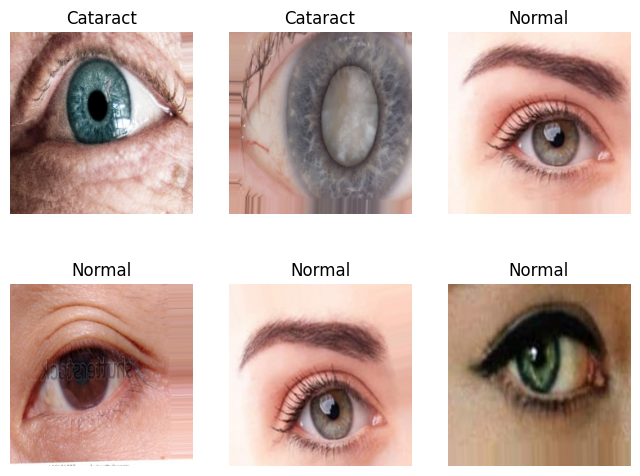

In [ ]:
# ================================
# STEP 3.4: VISUALIZE AUGMENTATION
# ================================

sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(8,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(sample_batch[i])
    plt.title("Cataract" if sample_labels[i]==0 else "Normal")
    plt.axis("off")

plt.show()

In [ ]:
# ================================
# STEP 4.1: LOAD EFFICIENTNET
# ================================
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
# ================================
# STEP 4.2: BUILD CNN MODEL
# ================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = 224

# Load base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Do NOT freeze completely — fine-tune later
base_model.trainable = True

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ================================
# STEP 4.3: COMPILE MODEL
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Cataract_dataset/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Cataract_dataset/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 488 images belonging to 2 classes.
Found 118 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 186s 9s/step - accuracy: 0.7459 - loss: 0.5325 - val_accuracy: 0.5847 - val_loss: 0.6895 - learning_rate: 1.0000e-04
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 138s 8s/step - accuracy: 0.9242 - loss: 0.1774 - val_accuracy: 0.6017 - val_loss: 0.6958 - learning_rate: 1.0000e-04
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 135s 8s/step - accuracy: 0.9570 - loss: 0.0966 - val_accuracy: 0.6864 - val_loss: 0.5684 - learning_rate: 1.0000e-04
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 151s 9s/step - accuracy: 0.9693 - loss: 0.0704 - val_accuracy: 0.7034 - val_loss: 0.5211 - learning_rate: 1.0000e-04
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 139s 9s/step - accuracy: 0.9877 - loss: 0.0513 - val_accuracy: 0.6695 - val_loss: 0.6038 - learning_rate: 1.0000e-04
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 133s 8s/step - accuracy: 0.9898 - loss: 0.0393 - val_accuracy: 0.6271 - val_loss: 0.7985 - learning_rate: 1.0000e-04
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 137s 8s/step - accuracy: 0.9918 

In [ ]:
loss, acc = model.evaluate(test_data)
print("Validation Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7034 - loss: 0.5211
Validation Accuracy: 0.7033898234367371


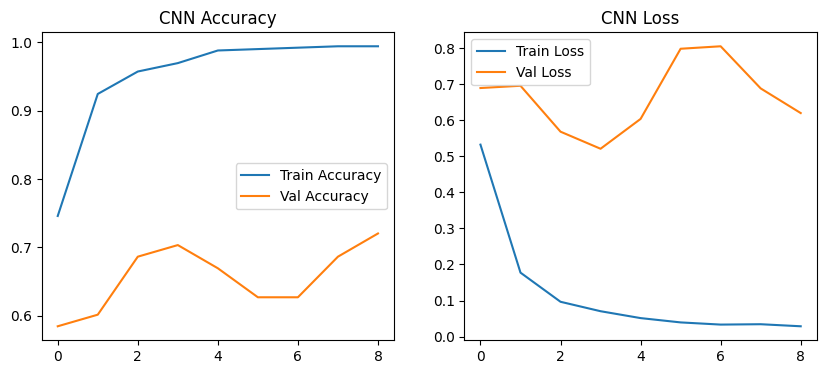

In [ ]:
# ================================
# STEP 4.5: TRAINING CURVES
# ================================
plt.figure(figsize=(10,4))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN Accuracy")
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("CNN Loss")
plt.show()

In [ ]:
# ================================
# STEP 4.6: CNN EVALUATION
# ================================
cnn_preds = model.predict(X_test)
cnn_preds = (cnn_preds > 0.5).astype(int).flatten()
cnn_acc = accuracy_score(y_test, cnn_preds)
print("CNN Test Accuracy:", cnn_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step
CNN Test Accuracy: 0.5


In [ ]:
# ================================
# STEP 5.1: CONVERT TO GRAYSCALE
# ================================
# Grayscale
X_train_gray = np.array([
    cv2.cvtColor((img*255).astype("uint8"), cv2.COLOR_RGB2GRAY)
    for img in X_train
])

X_test_gray = np.array([
    cv2.cvtColor((img*255).astype("uint8"), cv2.COLOR_RGB2GRAY)
    for img in X_test
])
print("Grayscale conversion completed.")
print("Train grayscale shape:", X_train_gray.shape)
print("Test grayscale shape :", X_test_gray.shape)

Grayscale conversion completed.
Train grayscale shape: (488, 224, 224)
Test grayscale shape : (118, 224, 224)


In [ ]:
# ================================
# STEP 5.2: GLCM FEATURE EXTRACTION
# ================================
from skimage.feature import graycomatrix, graycoprops
def extract_glcm_features(images):
  features = []

  for img in images:
    glcm = graycomatrix(
      img,
      distances=[1],
      angles=[0],
      levels=256,
      symmetric=True,
      normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    features.append([contrast, homogeneity, energy, correlation])

  return np.array(features)

In [ ]:
# ================================
# STEP 5.3: STATISTICAL FEATURES
# ================================
from scipy.stats import entropy

def extract_stat_features(images):
    features = []
    for img in images:
        hist = np.histogram(img.flatten(), bins=256, range=(0,256))[0]

        features.append([
            np.mean(img),
            np.std(img),
            np.var(img),
            entropy(hist + 1e-7)
        ])

    return np.array(features)

In [ ]:
# ================================
# STEP 5.4: FEATURE COMBINATION
# ================================
# Texture features
train_glcm = extract_glcm_features(X_train_gray)
test_glcm = extract_glcm_features(X_test_gray)

# Statistical features
train_stat = extract_stat_features(X_train_gray)
test_stat = extract_stat_features(X_test_gray)

# Combine features
X_train_features = np.hstack([train_glcm, train_stat])
X_test_features = np.hstack([test_glcm, test_stat])
print("Handcrafted feature shape (train):", X_train_features.shape)
print("Handcrafted feature shape (test) :", X_test_features.shape)

Handcrafted feature shape (train): (488, 8)
Handcrafted feature shape (test) : (118, 8)


In [ ]:
# ================================
# STEP 5.5: FEATURE SCALING
# ================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_features = scaler.fit_transform(X_train_features)
X_test_features = scaler.transform(X_test_features)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
# ================================
# STEP 5.6: TRAIN SVM
# ================================
svm_model = SVC(
  kernel='rbf',
  probability=True,
  random_state=42
)

svm_model.fit(X_train_features, y_train)
print("SVM model trained successfully.")


SVM model trained successfully.


In [ ]:
# ================================
# STEP 5.7: ML PREDICTIONS
# ================================
svm_preds = svm_model.predict(X_test_features)
svm_probs = svm_model.predict_proba(X_test_features)[:, 1]
svm_acc = accuracy_score(y_test, svm_preds)
print("SVM Test Accuracy:", svm_acc)


SVM Test Accuracy: 0.864406779661017


In [ ]:
# ================================
# STEP 6.1: CNN PROBABILITIES
# ================================
# CNN probability predictions
cnn_probs = model.predict(X_test).flatten()
# Binary predictions (threshold = 0.5)
cnn_preds = (cnn_probs > 0.5).astype(int)
print("CNN probabilities extracted.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
CNN probabilities extracted.


In [ ]:
# ================================
# STEP 6.2: SVM Probabilities
# ================================
# svm_probs already obtained earlier
# svm_probs = svm_model.predict_proba(X_test_features)[:, 1]
print("SVM probabilities ready.")

SVM probabilities ready.


In [ ]:
# ================================
# STEP 6.3: HYBRID FUSION
# ================================
alpha = 0.5 # CNN weight
beta = 0.5 # SVM weight
hybrid_probs = (alpha * cnn_probs) + (beta * svm_probs)
# Final hybrid predictions
hybrid_preds = (hybrid_probs > 0.5).astype(int)
print("Hybrid fusion completed.")


Hybrid fusion completed.


In [ ]:
# ================================
# STEP 6.4: HYBRID EVALUATION
# ================================
from sklearn.metrics import precision_score, recall_score, f1_score
hybrid_acc = accuracy_score(y_test, hybrid_preds)
hybrid_prec = precision_score(y_test, hybrid_preds)
hybrid_rec = recall_score(y_test, hybrid_preds)
hybrid_f1 = f1_score(y_test, hybrid_preds)
print("Hybrid Accuracy :", hybrid_acc)
print("Hybrid Precision:", hybrid_prec)
print("Hybrid Recall :", hybrid_rec)
print("Hybrid F1-score :", hybrid_f1)


Hybrid Accuracy : 0.5677966101694916
Hybrid Precision: 0.5363636363636364
Hybrid Recall : 1.0
Hybrid F1-score : 0.6982248520710059


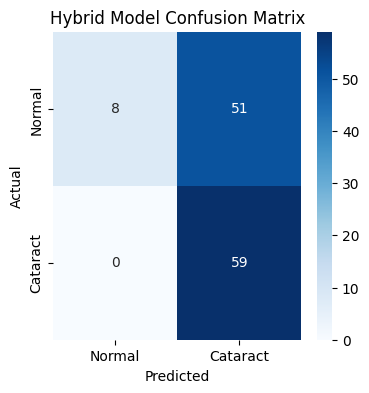

In [ ]:
# ================================
# STEP 6.5: CONFUSION MATRIX
# ================================
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, hybrid_preds)
plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Cataract"],
            yticklabels=["Normal", "Cataract"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")
plt.show()


In [ ]:
# ================================
# STEP 7.1: COLLECT RESULTS
# ================================
results = {
  "CNN": {
    "Accuracy": cnn_acc,
    "Precision": precision_score(y_test, cnn_preds),
    "Recall": recall_score(y_test, cnn_preds),
    "F1-score": f1_score(y_test, cnn_preds)
  },
  "SVM": {
    "Accuracy": svm_acc,
    "Precision": precision_score(y_test, svm_preds),
    "Recall": recall_score(y_test, svm_preds),
    "F1-score": f1_score(y_test, svm_preds)
  },
  "Hybrid": {
    "Accuracy": hybrid_acc,
    "Precision": hybrid_prec,
    "Recall": hybrid_rec,
    "F1-score": hybrid_f1
  }
}
results


{'CNN': {'Accuracy': 0.5,
  'Precision': 0.5,
  'Recall': 1.0,
  'F1-score': 0.6666666666666666},
 'SVM': {'Accuracy': 0.864406779661017,
  'Precision': 0.8524590163934426,
  'Recall': 0.8813559322033898,
  'F1-score': 0.8666666666666667},
 'Hybrid': {'Accuracy': 0.5677966101694916,
  'Precision': 0.5363636363636364,
  'Recall': 1.0,
  'F1-score': 0.6982248520710059}}

In [ ]:
# ================================
# STEP 7.2: RESULTS TABLE
# ================================
import pandas as pd
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-score
CNN,0.500000,0.500000,1.000000,0.666667
SVM,0.864407,0.852459,0.881356,0.866667
Hybrid,0.567797,0.536364,1.000000,0.698225


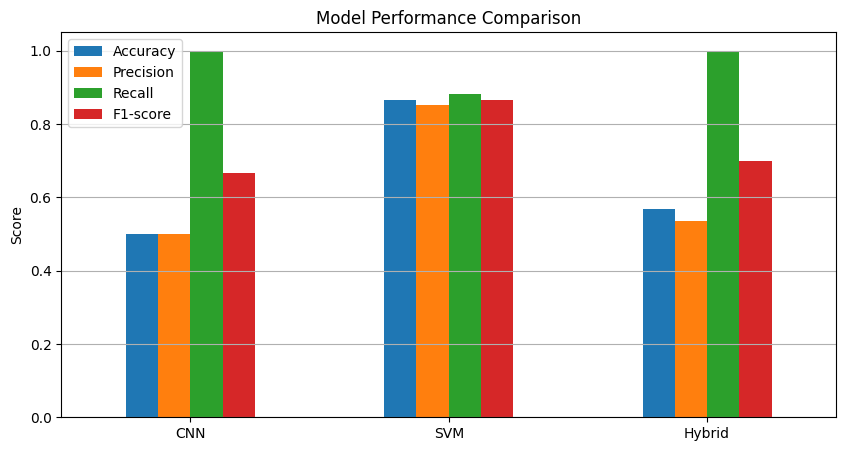

In [ ]:
# ================================
# STEP 7.3: PERFORMANCE COMPARISON
# ================================
results_df.plot(kind="bar", figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


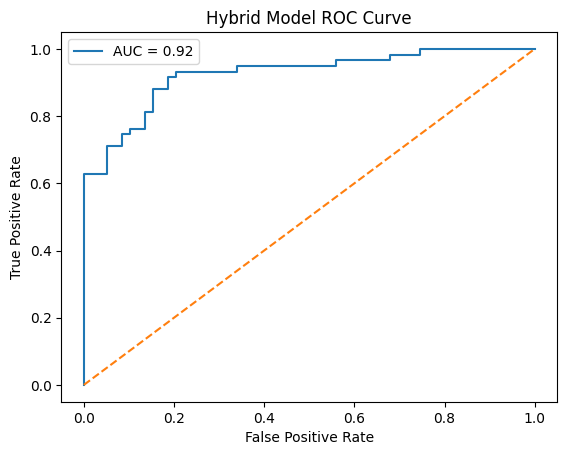

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, hybrid_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid Model ROC Curve")
plt.legend()
plt.show()

In [ ]:
for i in range(5):
  print(f"Prediction: {'Cataract' if hybrid_preds[i]==1 else 'Normal'} | Confidence: {hybrid_probs[i]:.2f}")

Prediction: Cataract | Confidence: 0.70
Prediction: Cataract | Confidence: 0.63
Prediction: Cataract | Confidence: 0.67
Prediction: Cataract | Confidence: 0.54
Prediction: Normal | Confidence: 0.50


In [ ]:
model.save("cnn_cataract_model.h5")
import joblib
joblib.dump(svm_model, "svm_cataract_model.pkl")


['svm_cataract_model.pkl']

In [ ]:
from google.colab import files

files.download("cnn_cataract_model.h5")
files.download("svm_cataract_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>